<a href="https://colab.research.google.com/github/Harsh3445/PFML-SEM-4/blob/main/skill_test_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
df=pd.read_csv("weather_data.csv")

In [ ]:
print(df.head())

         Date  Temperature (°C)  Humidity (%)  Wind Speed (km/h)  \
0  01-01-2025              15.2            80               10.5   
1  02-01-2025              16.8            75                8.0   
2  03-01-2025              14.5            85               12.0   
3  04-01-2025              13.0            90               15.2   
4  05-01-2025              17.6            70                7.4   

   Rainfall (mm)  
0            0.0  
1            0.0  
2            1.2  
3            5.4  
4            0.0  


In [ ]:
import pandas as pd
# Check for missing values
print(df.isnull().sum())

# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df['Temperature (°C)'] = df['Temperature (°C)'].fillna(df['Temperature (°C)'].mean())
df['Rainfall (mm)'] = df['Rainfall (mm)'].fillna(df['Rainfall (mm)'].mean())


Date                 0
Temperature (°C)     0
Humidity (%)         0
Wind Speed (km/h)    0
Rainfall (mm)        0
dtype: int64


In [ ]:
print(df.head())

        Date  Temperature (°C)  Humidity (%)  Wind Speed (km/h)  Rainfall (mm)
0 2025-01-01              15.2            80               10.5            0.0
1 2025-01-02              16.8            75                8.0            0.0
2 2025-01-03              14.5            85               12.0            1.2
3 2025-01-04              13.0            90               15.2            5.4
4 2025-01-05              17.6            70                7.4            0.0


In [ ]:
# Create a new column for the Month
df['Month'] = df['Date'].dt.strftime('%B') # Extracts full month name (e.g., January)

# Group by Month and calculate the average temperature
monthly_avg_temp = df.groupby('Month')['Temperature (°C)'].mean()

print(monthly_avg_temp)

Month
January    15.31
Name: Temperature (°C), dtype: float64


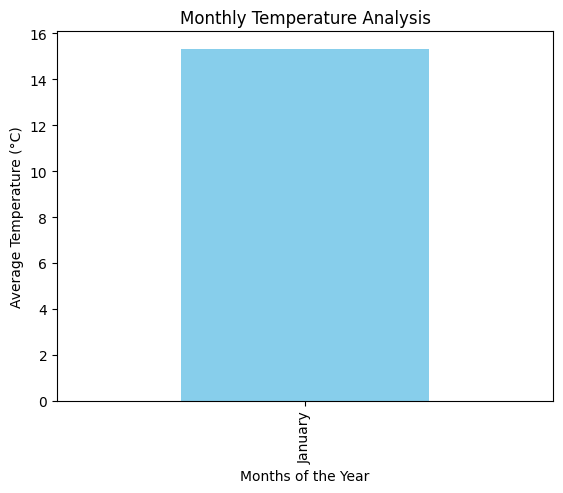

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv('weather_data.csv')

# 2. Fix dates and create a Month column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['Month'] = df['Date'].dt.month_name()

# 3. Calculate the average
summary = df.groupby('Month')['Temperature (°C)'].mean()

# 4. Create the plot
summary.plot(kind='bar', color='skyblue')

# 5. ADD THE LABELS (Important for your test!)
plt.title('Monthly Temperature Analysis')
plt.xlabel('Months of the Year') # <--- This identifies your X-axis
plt.ylabel('Average Temperature (°C)')

plt.show()

QUESTION 2

In [ ]:
import pandas as pd

# 1. LOAD THE DATA
df = pd.read_csv('student_score.csv')

# Task (a): DISPLAY SUMMARY STATISTICS
# .describe() gives you the mean, min, max, etc., for every subject automatically
print("--- Summary Statistics ---")
print(df[['Maths', 'Physics', 'Chemistry']].describe())

# Task (b): CALCULATE AVERAGE SCORE FOR EACH STUDENT
# We calculate the mean across the columns (axis=1) for each row
subjects = ['Maths', 'Physics', 'Chemistry']
df['Average'] = df[subjects].mean(axis=1)

print("\n--- Student Averages ---")
print(df[['Name', 'Average']])

# Task (c): IDENTIFY STUDENTS WHO SCORED BELOW 60 IN MORE THAN TWO SUBJECTS
# 1. Create a boolean table where score < 60 is True
below_60_count = (df[subjects] < 60).sum(axis=1)

# 2. Filter students where the count of subjects < 60 is greater than 2
# Note: Based on the table, only Frank Green has scores < 60, but only in 2 subjects.
struggling_students = df[below_60_count > 2]

print("\n--- Students scoring below 60 in more than 2 subjects ---")
if struggling_students.empty:
    print("No students found meeting this criteria.")
else:
    print(struggling_students['Name'])

--- Summary Statistics ---
           Maths    Physics  Chemistry
count  10.000000  10.000000  10.000000
mean   78.900000  79.100000  78.900000
std    11.618472  12.449453  11.080012
min    60.000000  55.000000  58.000000
25%    71.000000  72.750000  74.500000
50%    80.000000  79.000000  79.000000
75%    87.250000  87.250000  86.750000
max    95.000000  96.000000  94.000000

--- Student Averages ---
          Name    Average
0  Alice Brown  86.666667
1   Ben Carter  77.666667
2  Clara Davis  92.000000
3  David Evans  66.333333
4   Eva Foster  76.000000
5  Frank Green  57.666667
6   Grace Hall  86.333333
7   Henry Ives  72.000000
8   Isla Jones  95.000000
9    Jack King  80.000000

--- Students scoring below 60 in more than 2 subjects ---
No students found meeting this criteria.


Question 3

In [ ]:
import pandas as pd
import numpy as np

# --- STEP 1: CREATE RANDOM DATA ---
# We are making 10 students with random scores between 40 and 100
data = {
    'Student ID': range(101, 111),
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva', 'Frank', 'Grace', 'Henry', 'Isla', 'Jack'],
    'Maths': np.random.randint(40, 100, size=10),
    'Physics': np.random.randint(40, 100, size=10),
    'Chemistry': np.random.randint(40, 100, size=10)
}

df = pd.DataFrame(data)
print("--- Raw Student Data ---")
print(df)
print("-" * 30)

# --- STEP 2: PERFORM THE TASKS ---

# Task (a): Summary Statistics
# This shows the mean, min, max, etc. for each subject column
print("\n[A] Summary Statistics for each Subject:")
print(df[['Maths', 'Physics', 'Chemistry']].describe())

# Task (b): Average score for each student
# axis=1 means "calculate across the row" for that specific student
subjects = ['Maths', 'Physics', 'Chemistry']
df['Student_Average'] = df[subjects].mean(axis=1)

print("\n[B] Average Score per Student:")
print(df[['Name', 'Student_Average']])

# Task (c): Students scoring below 60 in more than two subjects
# 1. Check which scores are < 60
# 2. Sum how many 'True' values exist in each row
# 3. Filter for rows where that sum is greater than 2 (meaning failed all 3)
failed_counts = (df[subjects] < 60).sum(axis=1)
struggling = df[failed_counts > 2]

print("\n[C] Students who failed more than 2 subjects (scored < 60 in all 3):")
if struggling.empty:
    print("None of the students failed more than 2 subjects.")
else:
    print(struggling[['Name', 'Maths', 'Physics', 'Chemistry']])

--- Raw Student Data ---
   Student ID     Name  Maths  Physics  Chemistry
0         101    Alice     66       42         77
1         102      Bob     76       95         93
2         103  Charlie     53       82         48
3         104    David     94       59         49
4         105      Eva     62       89         45
5         106    Frank     64       84         56
6         107    Grace     45       93         87
7         108    Henry     44       59         83
8         109     Isla     68       46         65
9         110     Jack     75       55         64
------------------------------

[A] Summary Statistics for each Subject:
           Maths  Physics  Chemistry
count  10.000000  10.0000  10.000000
mean   64.700000  70.4000  66.700000
std    15.151458  20.2221  17.429541
min    44.000000  42.0000  45.000000
25%    55.250000  56.0000  50.750000
50%    65.000000  70.5000  64.500000
75%    73.250000  87.7500  81.500000
max    94.000000  95.0000  93.000000

[B] Average Score 